<a href="https://colab.research.google.com/github/uldopp/TMON/blob/main/KT_1_Class_1/KT_1_Class_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Классификация. 1 часть

In [24]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [8]:
df = pd.read_excel('diabetes.xlsx')

In [9]:
df.shape

(768, 9)

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


*   Pregnancies - Количество беременностей
*   Glucose - Концентрация глюкозы в плазме: 2 часа в пероральном тесте толерантности на глюкозу
*   BloodPressure - Диастолическое артериальное давление (мм рт. ст.)
*   SkinThickness - Толщина складок кожи трицепса (мм)
*   Insulin - 2-часовой сывороточный инсулин (mu U/ml)
*   BMI - Индекс массы тела (вес в кг/(рост в м)^2)
*   DiabetesPedigreeFunction - Функция родословной диабета
*   Age - Возраст (годы)
*   Outcome - Переменная класса (0 или 1)


In [11]:
import mpl_toolkits.mplot3d  # noqa: F401


from sklearn import datasets
from sklearn.cluster import KMeans

In [12]:
# Метод Pandas info()  выводит очень много информации о наборе данных - количество записей,
# количество ненулевых значений в каждом столбце, тип данных в столбце

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
# Pandas describe() используется для просмотра  основной статистической информации, таких как процентиль, среднее,
# стандартное отклонение и т.д. фрейма данных или ряда числовых значений:

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
df['Outcome'].unique()

array([1, 0])

In [16]:
# Теперь проверим количество строк, которое принадлежит каждому классу:

df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


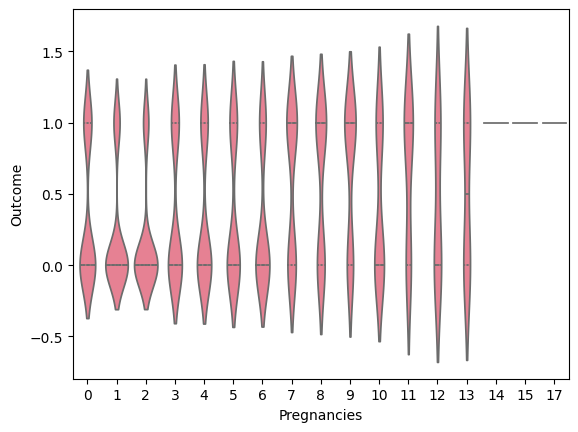

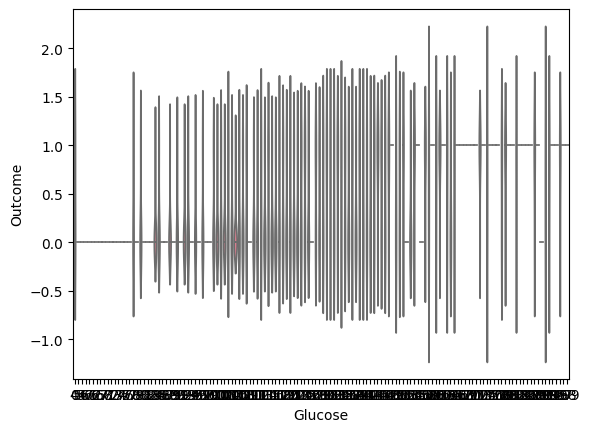

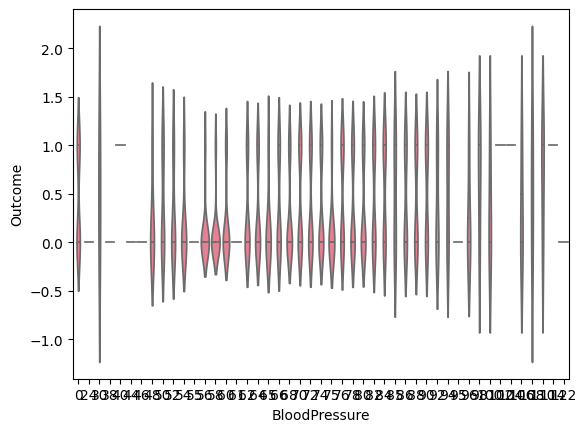

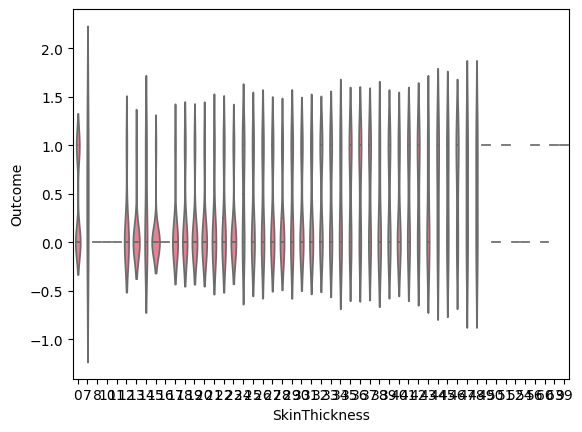

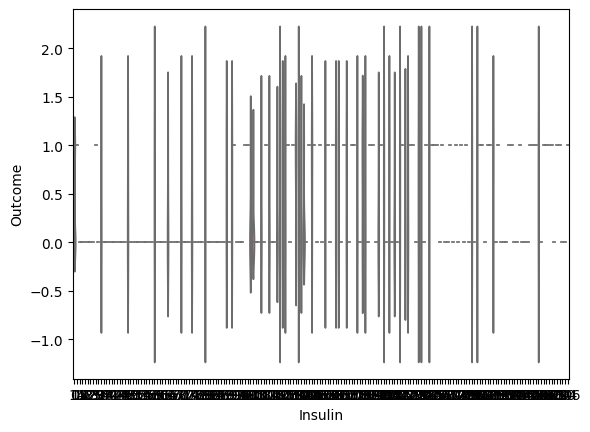

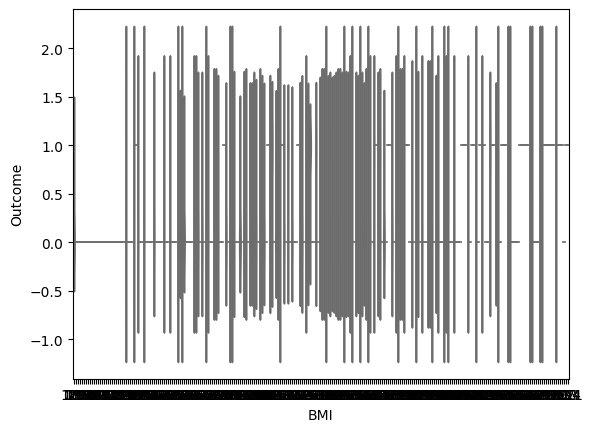

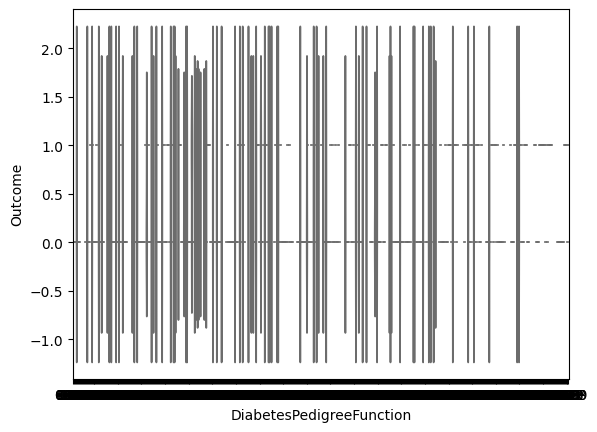

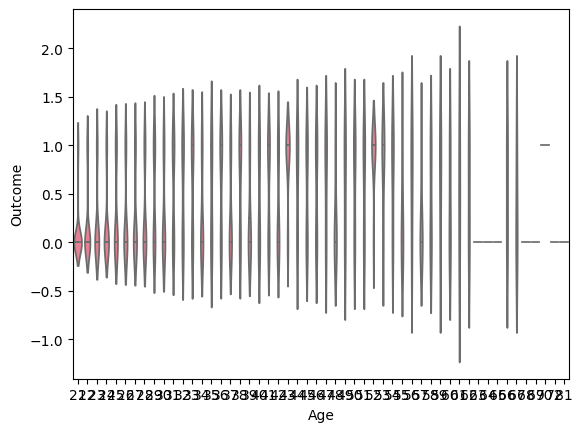

In [17]:
# Скрипичный график.
# Используется для проверки сравнения распределения переменных:

sns.violinplot(y='Outcome', x='Pregnancies', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Outcome', x='Glucose', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Outcome', x='BloodPressure', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Outcome', x='SkinThickness', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Outcome', x='Insulin', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Outcome', x='BMI', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Outcome', x='DiabetesPedigreeFunction', data=df, inner='quartile')
plt.show()
sns.violinplot(y='Outcome', x='Age', data=df, inner='quartile')
plt.show()

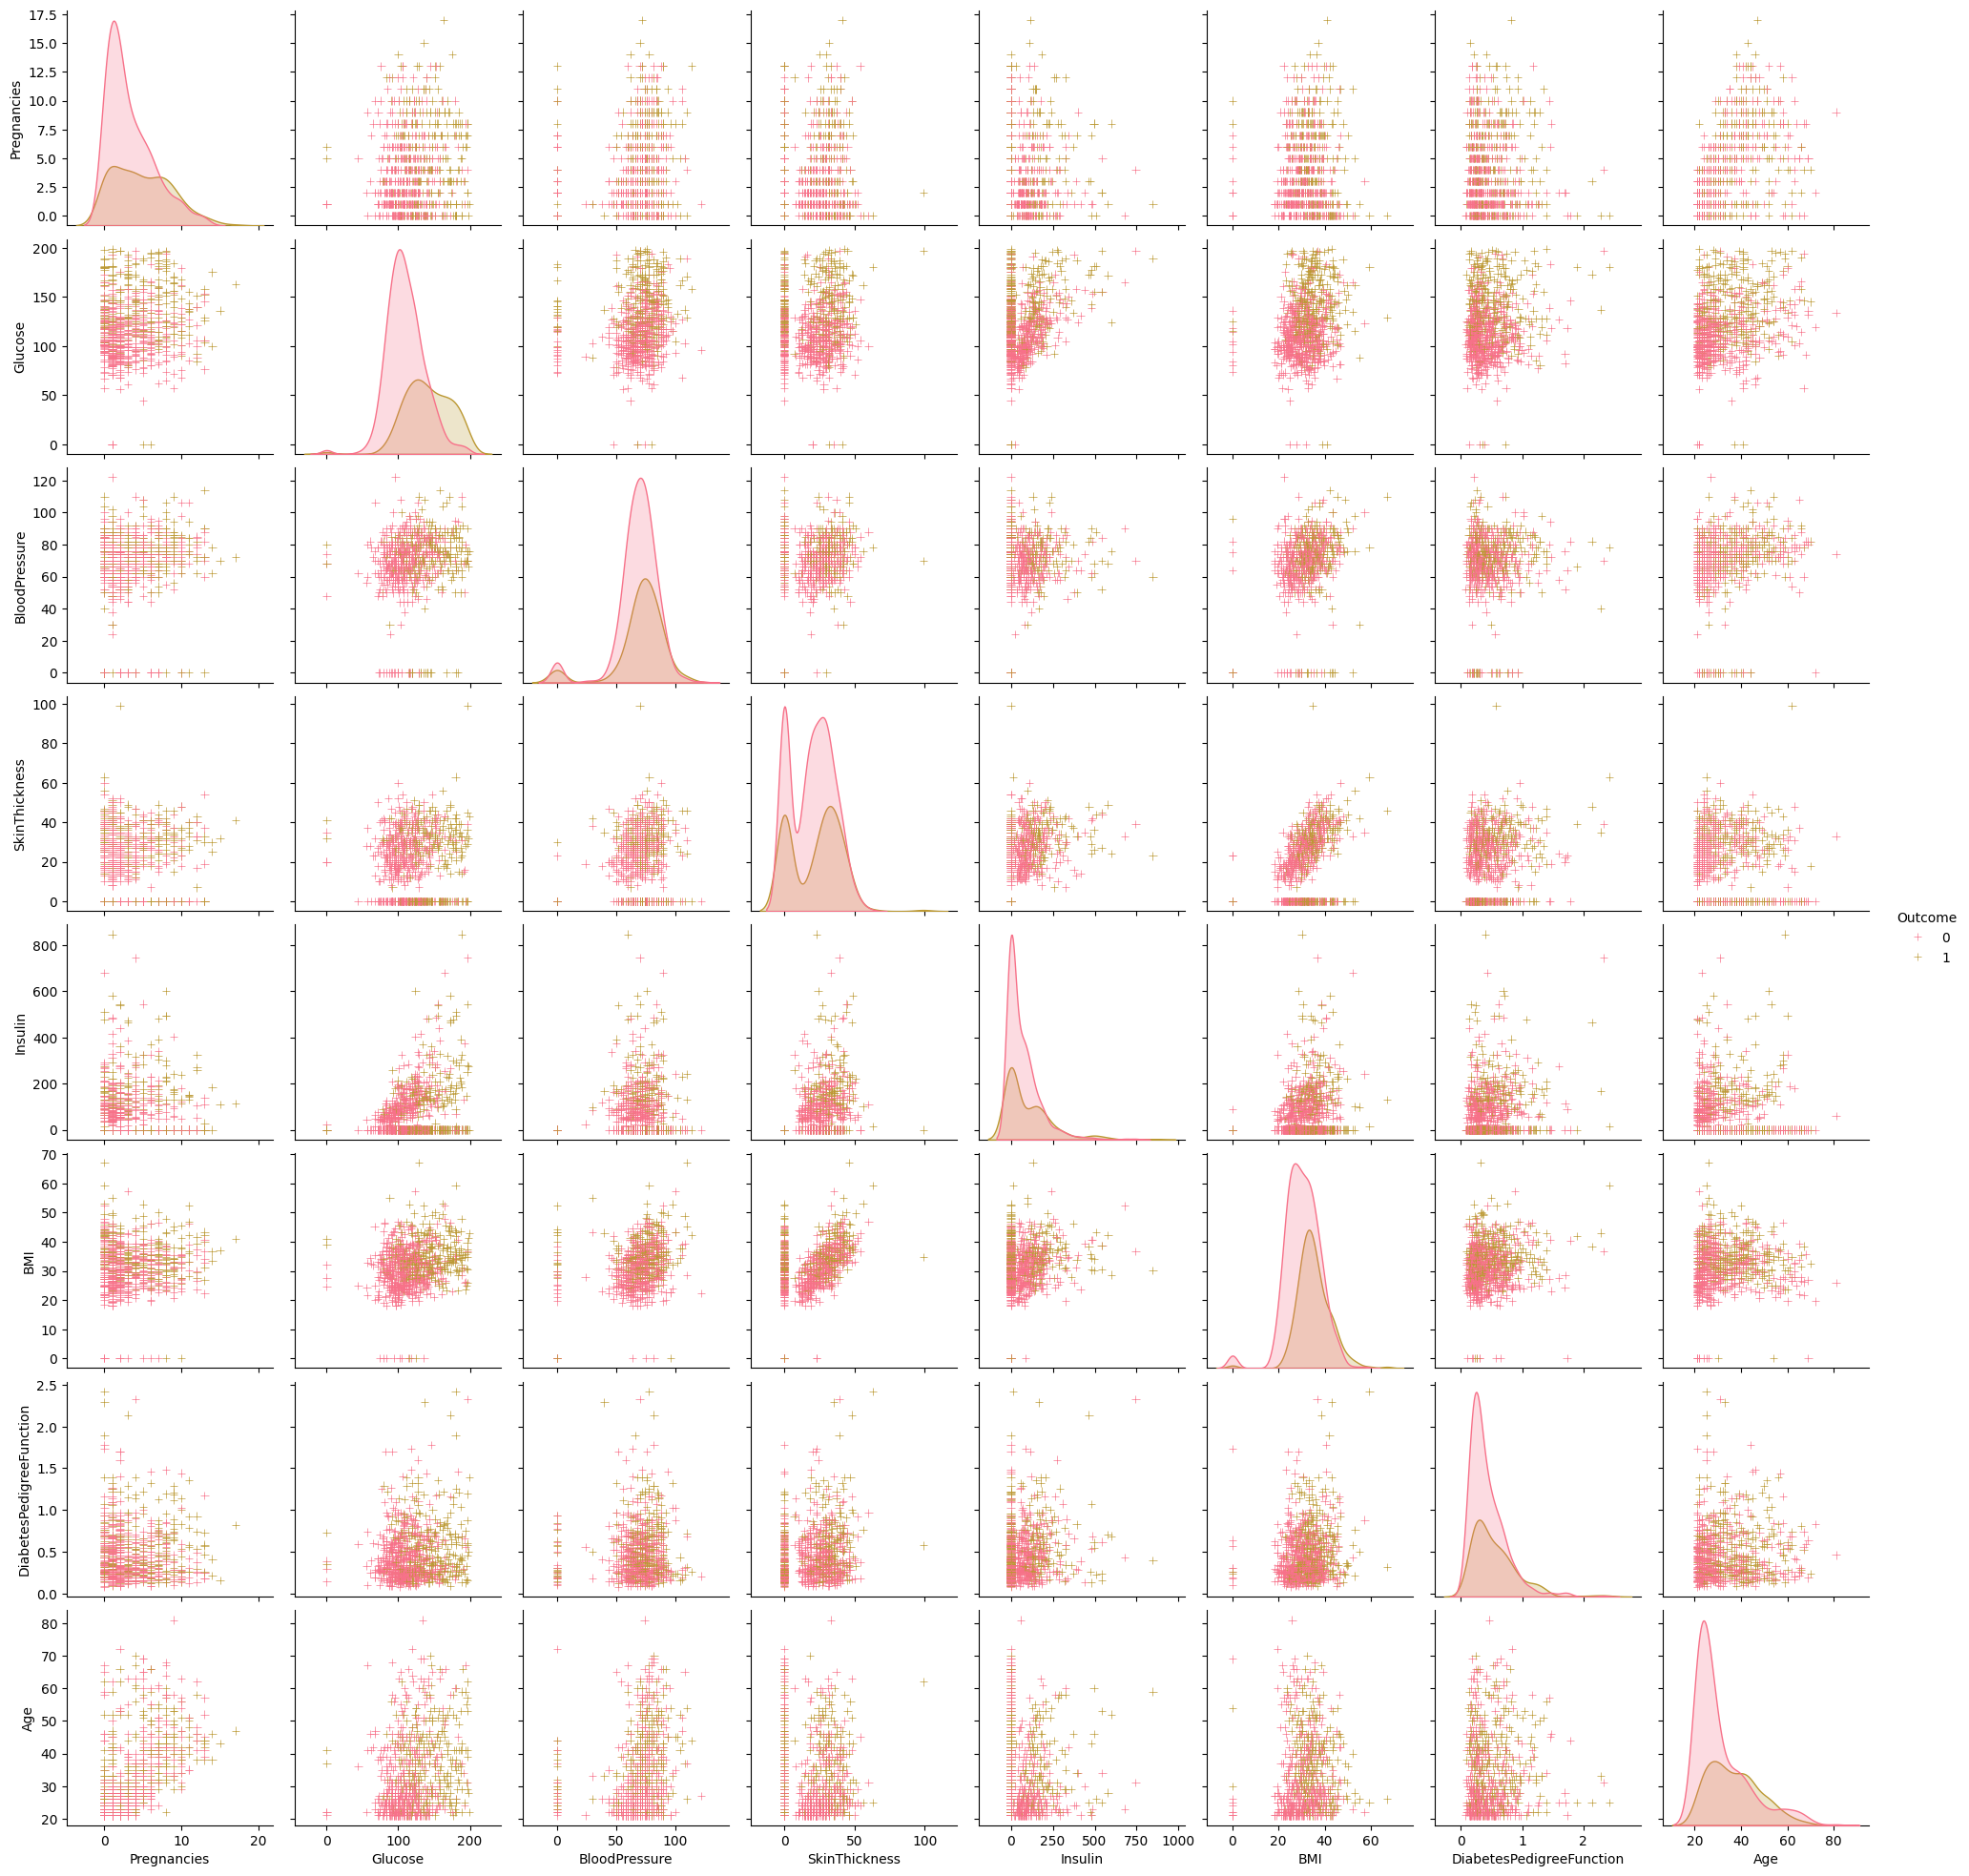

In [18]:
# Парный график
#Построение нескольких попарных двумерных распределений в наборе данных с помощью pairplot:

sns.pairplot(df, hue='Outcome', markers='+')
plt.show()

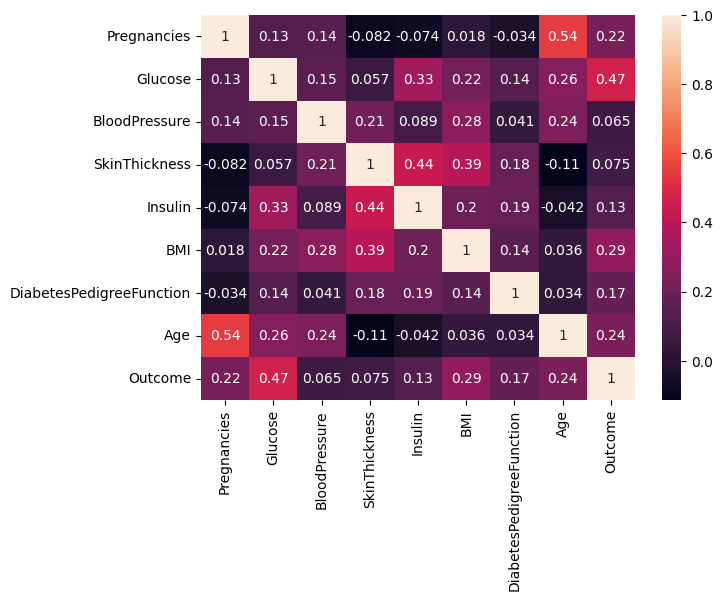

In [19]:
# Тепловая карта
# Построение тепловой карты для проверки корреляции.
# dataset.corr() используется для поиска попарной корреляции всех столбцов в кадре данных.

plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only = True), annot=True)
plt.show()

In [22]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (768, 8) | y shape: (768,) 


X имеет 768 строк и 8 столбцов, тогда как Y имеет 768 строк и только один столбец.

Разделяем наш набор данных на обучающий (train) и тестовый (test) с помощью `train_test_split()`, мы берем 80% данных для обучения нашей модели и 20% оставляем в качестве проверочного набора данных:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

In [29]:
import scipy.stats as stats

y_mapped = y

# почему важно перемешивать и делать train и test статистически не различимыми по целевой переменной
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.30, shuffle=True)

stats.ttest_ind (a=y_train, b=y_test)

TtestResult(statistic=np.float64(-1.8822602083005584), pvalue=np.float64(0.06017953893577618), df=np.float64(766.0))

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.20, random_state=15, stratify=y_mapped)

stats.ttest_ind (a=y_train, b=y_test)

TtestResult(statistic=np.float64(-0.04917542486646464), pvalue=np.float64(0.9607923146231533), df=np.float64(766.0))

Обучение и выбор оптимальной модели
Далее попробуем следующие алгоритмы:

* Logistic Regression (LR)
* Linear Discriminant Analysis (LDA)
* K-Nearest Neighbors (KNN)
* Classification and Regression Trees (CART)
* Gaussian Naive Bayes (NB)
* Support Vector Machines (SVM)

In [31]:
# создаем лист для тех моделей, которые будем изучать
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))

# оцениваем их метрики
results = []
model_names = []
for name, model in models:
  kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  model_names.append(name)
  print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.765230 (0.087900)
LDA: 0.763617 (0.093667)
KNN: 0.708435 (0.068876)
CART: 0.705182 (0.069128)
NB: 0.763776 (0.078144)
SVC: 0.651507 (0.005181)


NB, LR и LDA  показали лучшие метрики среди всех алгоритмов. Далее работаем с LinearDiscriminantAnalysis.

Давайте обучим модель NB на нашем обучающем наборе и сделаем прогноз на тестовом наборе на следующем шаге.

Gaussian Naive Bayes (Гауссовский наивный байесовский классификатор) — это алгоритм машинного обучения для классификации, основанный на теореме Байеса.

Это семейство алгоритмов, основанных на двух главных идеях:

* Теорема Байеса: Это математический способ пересчитать вероятность события, имея некую дополнительную информацию. Если коротко, мы пытаемся ответить на вопрос: "Какова вероятность того, что этот пациент болен (Outcome=1), учитывая, что у него такие-то показатели (глюкоза = 150, возраст = 45 и т.д.)?"

* "Наивное" допущение: Алгоритм предполагает, что все признаки (колонки) независимы друг от друга. Он "наивно" считает, что уровень глюкозы никак не связан с возрастом, а возраст не связан с ИМТ.

Это дополнение говорит о том, как именно алгоритм оценивает данные. Он предполагает, что значения числовых признаков (например, глюкоза, возраст, давление) внутри каждого класса распределены по нормальному (Гауссовскому) распределению (колоколообразной кривой).

* Для класса "Здоров" (Outcome=0) алгоритм строит свою колоколообразную кривую для уровня глюкозы.

* Для класса "Болен" (Outcome=1) — свою.

Когда приходит новый пациент, алгоритм смотрит: "На какую кривую больше похоже значение его глюкозы? На кривую здоровых или на кривую больных?".

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#Обучаем модель Naive Bayes (NB)
print("\n--- Модель 1: Gaussian Naive Bayes (NB) ---")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f'NB accuracy: {accuracy_nb}') #общая доля правильных ответов.
#Из 100 предсказаний модель ошибается примерно в 28 случаях.
print(f'NB prediction: {y_pred_nb}')
print("\nМатрица ошибок (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred_nb))
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred_nb, target_names=['Нет диабета (0)', 'Диабет (1)']))


--- Модель 1: Gaussian Naive Bayes (NB) ---
NB accuracy: 0.7207792207792207
NB prediction: [0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0
 0 0 1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1
 0 0 1 0 1 0]

Матрица ошибок (Confusion Matrix):
[[81 19]
 [24 30]]

Отчет по классификации:
                 precision    recall  f1-score   support

Нет диабета (0)       0.77      0.81      0.79       100
     Диабет (1)       0.61      0.56      0.58        54

       accuracy                           0.72       154
      macro avg       0.69      0.68      0.69       154
   weighted avg       0.72      0.72      0.72       154



Строки - факт, столбцы: предсказано.

TN (True Negatives): Модель сказала "Здоров", и человек действительно здоров. (81)

FP (False Positives): Модель сказала "Болен", а человек здоров (ложная тревога). Ошибка I рода. (18)

FN (False Negatives): Модель сказала "Здоров", а человек болен (пропустили болезнь). Ошибка II рода. (24)

TP (True Positives): Модель сказала "Болен", и человек действительно болен. (27)


=== Визуализация 1: Glucose vs Age ===
Точность NB на 2 признаках (Glucose, Age): 0.7403


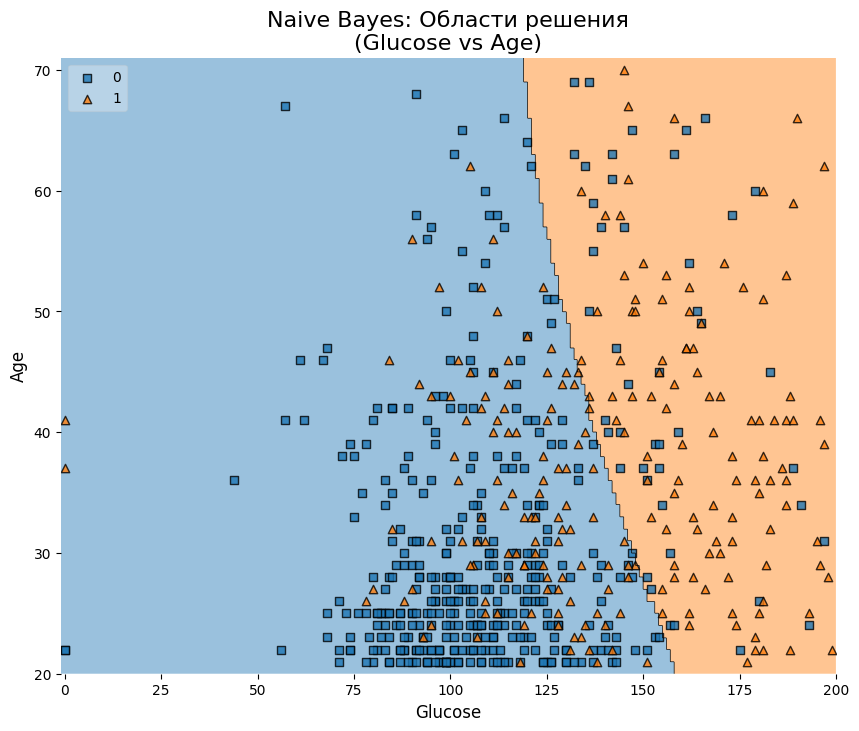

In [42]:

from mlxtend.plotting import plot_decision_regions
feature1 = 'Glucose'
feature2 = 'Age'
print(f"\n=== Визуализация 1: {feature1} vs {feature2} ===")
# Создаем 2D матрицу признаков для визуализации
X_2d = X_train[[feature1, feature2]].values
y_2d = y_train.values
# Обучаем Naive Bayes на двух признаках
nb_2d = GaussianNB()
nb_2d.fit(X_2d, y_2d)
# Точность модели на тестовых данных (только для этих двух признаков)
X_test_2d = X_test[[feature1, feature2]].values
accuracy_2d = nb_2d.score(X_test_2d, y_test)
print(f"Точность NB на 2 признаках ({feature1}, {feature2}): {accuracy_2d:.4f}")
# Визуализация областей решения
plt.figure(figsize=(10, 8))
plot_decision_regions(X=X_2d, y=y_2d, clf=nb_2d, legend=2)
plt.xlabel(feature1, fontsize=12)
plt.ylabel(feature2, fontsize=12)
plt.title(f'Naive Bayes: Области решения\n({feature1} vs {feature2})', fontsize=16)
plt.show()

In [ ]:
from mlxtend.plotting import plot_decision_regions

# Создаем 2D матрицу признаков для визуализации

y_s = y_train
X_2d= X_train[['Glucose',	'BMI']].values
y_2d = y_s.values

# Обучаем Naive Bayes на двух признаках
nb_2d = GaussianNB()
nb_2d.fit(X_2d, y_2d)

plt.title('LDA surface with original features')
plot_decision_regions(
    	X=X_2d,
    	y=y_2d,
    	clf=sk_lda1)